In [92]:
from harris import get_harris_corners,dist2
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2
from skimage.feature import peak_local_max
from skimage import io, color
from skimage.transform import resize
from scipy.spatial.distance import cdist

In [93]:
im = color.rgb2gray(io.imread('media/schright.jpg'))

In [94]:
h, coords = get_harris_corners(im)

In [95]:
filter = peak_local_max(h,min_distance=50)

In [96]:
# applying filtered min distance so we don't make every pixel a corner
edge = 20
mask = (filter[:,0] > edge) & (filter[:,0] < im.shape[0]-edge) & \
        (filter[:,1] > edge) & (filter[:,1] < im.shape[1]-edge)
filter = filter[mask]
coords = filter.T

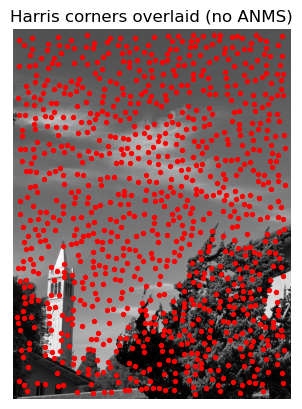

In [97]:
plt.imshow(im, cmap='gray')
plt.scatter(coords[1], coords[0], c='r', s=8)
plt.title('Harris corners overlaid (no ANMS)')
plt.axis('off')
plt.show()

Implementing Adaptive Non-Maximal Suppression (ANMS) 

In [98]:
def anms(coords, h, num_points=500, c_robust=0.9): #dont want every pixel, just pick top 500
  
    ys, xs = coords  
    N = len(xs)
    strengths = h[ys, xs]  #harris corner strengths
    r = np.full(N, np.inf)

    pts = np.stack([ys, xs], axis=1)  
    D = dist2(pts, pts)               
    D[D == 0] = np.inf            

    for i in range(N):
        mask = strengths[i] < c_robust * strengths  
        if np.any(mask):
            r[i] = np.min(D[i, mask])

    # Choose top points with largest radius => more priority for strong points in weak areas compared to strong points in strong areas
    top_idx = np.argsort(r)[::-1][:min(num_points, N)]
    return ys[top_idx], xs[top_idx]

In [99]:
strengths = h[coords[0], coords[1]]
strong_idx = np.argsort(strengths)[::-1][:2000]
coords = coords[:, strong_idx]

# applying anms
ys, xs = anms(coords, h, num_points=500)

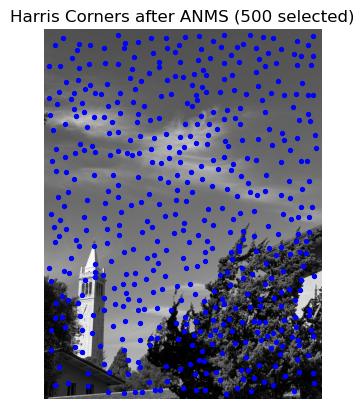

In [100]:
plt.imshow(im, cmap='gray')
plt.scatter(xs, ys, c='blue', s=8)
plt.title('Harris Corners after ANMS (500 selected)')
plt.axis('off')
plt.show()

In [101]:
print("Before ANMS:", coords.shape[1], "points")
print("After ANMS:", len(xs), "points")

Before ANMS: 933 points
After ANMS: 500 points


In [102]:
# for part 2, need to downsize the crop around each corner
def extraction(im,ys,xs,windowSize=40,finalSize=8):
    decrease = []
    half = windowSize//2
    #joining the tuples of coordinates together by order
    for y,x in zip(ys,xs):
        if y<half or y>=im.shape[0]-half or x<half or x>=im.shape[1]-half:
            continue
        
        window = im[int(y-half):int(y+half),int(x-half):int(x+half)] #40x40 crop
        downScale = resize(window,(finalSize,finalSize))
        assert downScale.shape == (finalSize, finalSize), f"Got shape {downScale.shape}"
        #bias/gain normalisation
        std=np.std(downScale)
        avg = np.mean(downScale)
        if std<0.00001:
            continue
        normalised = (downScale-avg)/std
        decrease.append(normalised.flatten())
    return np.array(decrease)

In [103]:
strengths = h[coords[0], coords[1]]
strong_idx = np.argsort(strengths)[::-1][:2000]
coords = coords[:, strong_idx]

# applying anms
ys, xs = anms(coords, h, num_points=500)

In [104]:
descs = extraction(im, ys, xs)
print("Extracted descriptors:", descs.shape)

Extracted descriptors: (500, 64)


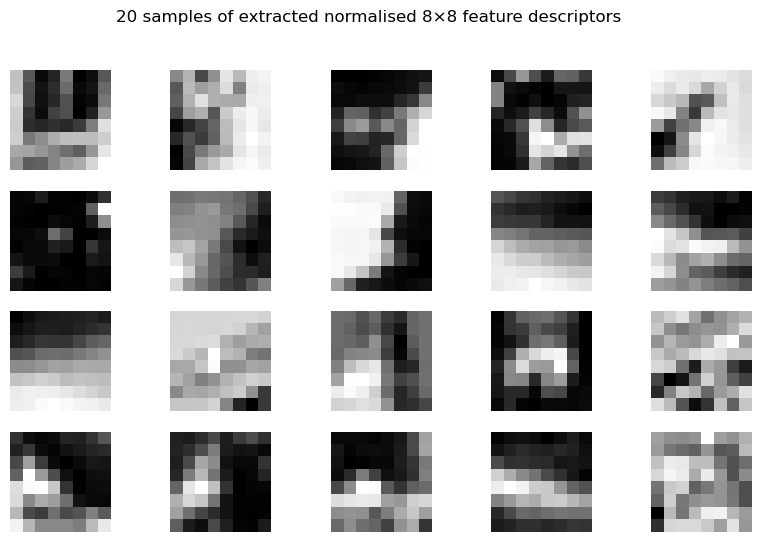

In [105]:
fig, axes = plt.subplots(4, 5, figsize=(10,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(descs[i].reshape(8,8), cmap='gray')
    ax.axis('off')
plt.suptitle("20 samples of extracted normalised 8×8 feature descriptors")
plt.show()

Part 3: Feature matching

In [106]:
im2 = color.rgb2gray(io.imread('media/schleft.jpg'))

In [107]:
h2, coords2 = get_harris_corners(im2)

In [108]:
strengths2 = h2[coords2[0], coords2[1]]
strong_idx2 = np.argsort(strengths2)[::-1][:2000]
coords2 = coords2[:, strong_idx2]

# applying anms
ys2, xs2 = anms(coords2, h2, num_points=500)

In [109]:
ys2, xs2 = anms(coords2, h2, num_points=500)
descs2 = extraction(im2, ys2, xs2)

In [110]:
#computing euclidean distance between feature descriptors
distance = cdist(descs,descs2,metric='euclidean')

In [111]:
# according to MOPS, the threshold for ratio test should be at a fraction of the outlier distance, about 0.65
# to ensure the best match is significantly better than the next best, reducing bad matches
def matchFeature(descs, descs2,threshold=0.65):
    match = []
    for i in range(distance.shape[0]):
        sorted_idx = np.argsort(distance[i])
        j1, j2 = sorted_idx[0], sorted_idx[1]
        d1, d2 = distance[i, j1], distance[i, j2]

        if d1/d2 < threshold: #lowe ratio test
            match.append((i, j1)) #good match
    return np.array(match)

In [126]:
match = matchFeature(descs, descs2, threshold=0.7)
print("Total matches:", len(match))

Total matches: 10


In [127]:
def showMatch(im, im2, ys, xs, ys2, xs2, match, num_show=50):
    h1, w1 = im.shape
    canvas = np.hstack((im, im2))
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(canvas, cmap='gray')
    
    for k, (i, i2) in enumerate(match[:num_show]):
        y1, x1 = ys[i], xs[i]
        y2, x2 = ys2[i2], xs2[i2]
        color = np.random.rand(3) #so can easily see lines
        ax.plot([x1, x2 + w1], [y1, y2], '-', color=color, linewidth=1)
        ax.scatter([x1, x2 + w1], [y1, y2], color=color, s=8)
    
    ax.axis('off')
    plt.title(f"Matched features ({min(num_show, len(match))} Points, threshold = 0.7)")
    plt.show()

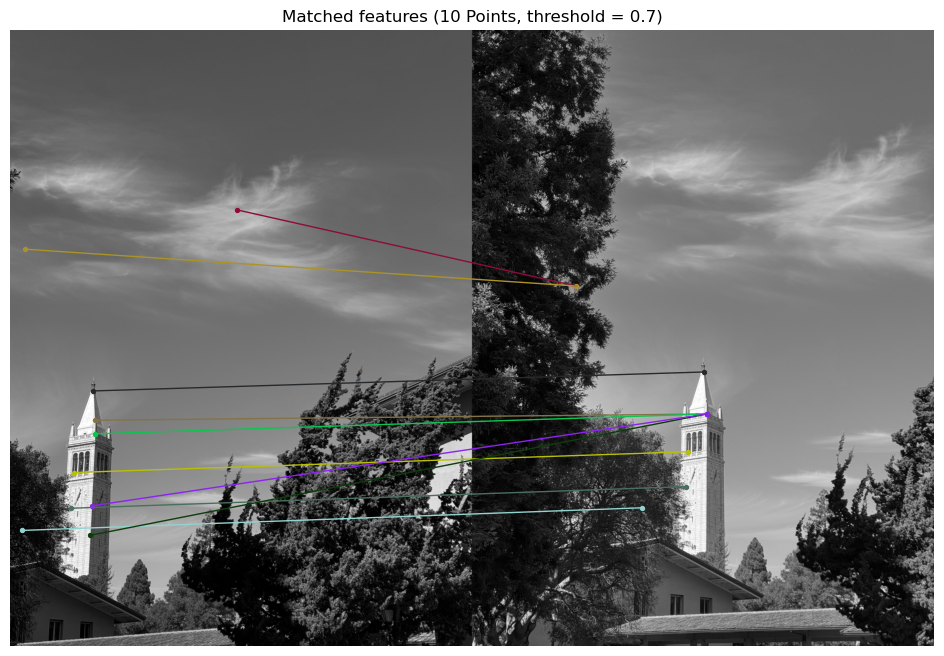

In [128]:
showMatch(im, im2, ys,xs, ys2, xs2, match)
# ok to have some mismatch because we doing pure appearance-based matching, which compares 8×8 grayscale patches for similarity.


Part 4: RANSAC for robust homography

In [115]:
#compute H function
def computeH(pts, pts2):
    A = []
    for i in range(4):
        x, y = pts[i]
        xp, yp = pts2[i]
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])
    
    A = np.array(A)
    
    #use SVD to factorise and breakdown matrix into smaller matrices
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)
    
    #normalise
    H = H / H[2, 2]
    return H

In [116]:
#apply homography transformation to pointss
def applyH(H, pts):
    pts_homogeneous = np.hstack([pts, np.ones((pts.shape[0], 1))])
    transformed = (H @ pts_homogeneous.T).T
    
    # Convert back from homogeneous coordinates
    transformed_pts = transformed[:, :2] / transformed[:, 2:3]
    return transformed_pts

In [117]:
# based on reprojection error, compute inliers
def compute_inliers(H, pts, pts2, threshold=3.0):
    transformed_pts = applyH(H, pts)
    distances = np.linalg.norm(transformed_pts - pts2, axis=1)
    inliers = distances < threshold
    return inliers, np.sum(inliers)

In [118]:
# ransac algo
def ransacH(pts, pts2, num_iterations=1000, threshold=3.0):
    n_points = pts.shape[0]
    #init all at none
    best_inliers = None 
    best_num_inliers = 0
    best_H = None
    
    for iteration in range(num_iterations):
        # Randomly sample 4 point correspondences
        indices = random.sample(range(n_points), 4)
        sample_src = pts[indices]
        sample_dst = pts2[indices]
        
        try:
            # Compute homography from 4 points
            H = computeH(sample_src, sample_dst)
            
            # Compute inliers
            inliers, num_inliers = compute_inliers(H, pts, pts2, threshold)
            
            # Update best model if current is better
            if num_inliers > best_num_inliers:
                best_num_inliers = num_inliers
                best_inliers = inliers
                best_H = H
                
        except np.linalg.LinAlgError:
            # Skip degenerate configurations
            continue
    
    # Optional: Refine using all inliers
    if best_H is not None and best_num_inliers >= 4:
        try:
            inlier_src = pts[best_inliers]
            inlier_dst = pts2[best_inliers]
            
            # Use least squares with all inliers for better estimate
            A = []
            for i in range(len(inlier_src)):
                x, y = inlier_src[i]
                xp, yp = inlier_dst[i]
                A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
                A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])
            
            A = np.array(A)
            _, _, Vt = np.linalg.svd(A)
            H_refined = Vt[-1].reshape(3, 3)
            H_refined = H_refined / H_refined[2, 2]
            
            # Verify refined homography is still good
            inliers_refined, num_inliers_refined = compute_inliers(
                H_refined, pts, pts2, threshold
            )
            if num_inliers_refined >= best_num_inliers:
                best_H = H_refined
                best_inliers = inliers_refined
                best_num_inliers = num_inliers_refined
                
        except np.linalg.LinAlgError:
            pass
    
    return best_H, best_inliers, best_num_inliers

In [119]:
# converting ANMS points of correspondence to arrays
pts  = np.array([[xs[i], ys[i]] for i, _ in match])    
pts2 = np.array([[xs2[j], ys2[j]] for _, j in match]) 

In [137]:
H1, inliers, num_inliers = ransacH(pts2, pts, num_iterations=2000, threshold=3.0) 
#adjust these parameters for more robustness

print(f"Found {num_inliers} inliers out of {len(pts)} total matches")
print(f"Inlier ratio: {num_inliers/len(pts)*100:.1f}%")
print(f"Homography matrix:\n{H1}") # this H is already computed from inliers, and can be used directly

clean_pts = pts[inliers]
clean_pts2 = pts2[inliers]

Found 5 inliers out of 13 total matches
Inlier ratio: 38.5%
Homography matrix:
[[ 1.10907078e+00 -3.45176434e-02 -1.04001358e+03]
 [ 6.64692208e-02  1.05684508e+00 -2.34956200e+01]
 [ 2.30861150e-05 -3.85503462e-07  1.00000000e+00]]


/var/folders/v7/889bwxmn2w33rklr43ynm2qr0000gn/T/ipykernel_73463/3226569987.py:7: RuntimeWarning: divide by zero encountered in divide
  transformed_pts = transformed[:, :2] / transformed[:, 2:3]
/var/folders/v7/889bwxmn2w33rklr43ynm2qr0000gn/T/ipykernel_73463/3226569987.py:7: RuntimeWarning: invalid value encountered in divide
  transformed_pts = transformed[:, :2] / transformed[:, 2:3]


In [138]:
# using the homography to stitch images together now but this is different form part A bilinear warping and stitching
#canvas size
def get_mosaic_canvas_size(img1, img2, H):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    
    # img2 corners
    corners_img2 = np.array([[0, 0],[w2, 0],[w2, h2],[0, h2]], dtype=np.float32)
    
    # transform corners
    corners_img2_homogeneous = np.hstack([corners_img2, np.ones((4, 1))])
    transformed_corners = (H @ corners_img2_homogeneous.T).T
    transformed_corners = transformed_corners[:, :2] / transformed_corners[:, 2:3]
    
    corners_img1 = np.array([[0, 0],[w1, 0],[w1, h1],[0, h1]], dtype=np.float32)
    
    # Combinecorners
    all_corners = np.vstack([corners_img1, transformed_corners])
    min_x, min_y = np.floor(all_corners.min(axis=0)).astype(int)
    max_x, max_y = np.ceil(all_corners.max(axis=0)).astype(int)

    canvas_width = max_x - min_x
    canvas_height = max_y - min_y
    
    # off set for negative coords
    offset_x = -min_x if min_x < 0 else 0
    offset_y = -min_y if min_y < 0 else 0
    
    return (canvas_width, canvas_height), (offset_x, offset_y)

In [139]:
def create_mosaic(img1, img2, H, blend_width=50):
    #canvas size + offset
    (canvas_width, canvas_height), (offset_x, offset_y) = get_mosaic_canvas_size(img1, img2, H)
    
    # translation matrix
    translation_matrix = np.array([[1, 0, offset_x],[0, 1, offset_y],[0, 0, 1]], dtype=np.float32)
    
    # first homgoraphy, then translate
    H_translated = translation_matrix @ H
    
    # Warp img2 to canvas
    img2_warped = cv2.warpPerspective(img2, H_translated, (canvas_width, canvas_height),flags=cv2.INTER_LINEAR)
    
    #im1 canvas
    canvas_img1 = np.zeros((canvas_height, canvas_width, 3), dtype=np.uint8)
    
    # Place img1 on canvas with offset
    canvas_img1[offset_y:offset_y+img1.shape[0], offset_x:offset_x+img1.shape[1]] = img1
    
    # Create masks
    mask1 = (canvas_img1.sum(axis=2) > 0).astype(np.uint8) * 255
    mask2 = (img2_warped.sum(axis=2) > 0).astype(np.uint8) * 255
    
    # Alpha blending
    dist1 = cv2.distanceTransform(mask1, cv2.DIST_L2, 5)
    dist2 = cv2.distanceTransform(mask2, cv2.DIST_L2, 5)
    overlap_mask = (mask1 > 0) & (mask2 > 0)

    alpha1 = np.zeros((canvas_height, canvas_width), dtype=np.float32)
    alpha2 = np.zeros((canvas_height, canvas_width), dtype=np.float32)
    alpha1[mask1 > 0] = 1.0
    alpha2[mask2 > 0] = 1.0
    
    if overlap_mask.any():
        total_dist = dist1 + dist2
        total_dist[total_dist == 0] = 1  
        alpha1[overlap_mask] = dist1[overlap_mask] / total_dist[overlap_mask]
        alpha2[overlap_mask] = dist2[overlap_mask] / total_dist[overlap_mask]
    
    # Blend images tgt
    mosaic = np.zeros_like(canvas_img1, dtype=np.float32)
    for c in range(3):
        mosaic[:, :, c] = (canvas_img1[:, :, c] * alpha1 + img2_warped[:, :, c] * alpha2)
    
    return mosaic.astype(np.uint8)

In [140]:
img1 = cv2.cvtColor(cv2.imread("media/schright.jpg"), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread("media/schleft.jpg"), cv2.COLOR_BGR2RGB)

In [141]:
#recalculating. for stability
H2, inliers,_ = ransacH(pts2, pts)

mosaic = create_mosaic(img1, img2, H2)

/var/folders/v7/889bwxmn2w33rklr43ynm2qr0000gn/T/ipykernel_73463/3226569987.py:7: RuntimeWarning: divide by zero encountered in divide
  transformed_pts = transformed[:, :2] / transformed[:, 2:3]
/var/folders/v7/889bwxmn2w33rklr43ynm2qr0000gn/T/ipykernel_73463/3226569987.py:7: RuntimeWarning: invalid value encountered in divide
  transformed_pts = transformed[:, :2] / transformed[:, 2:3]


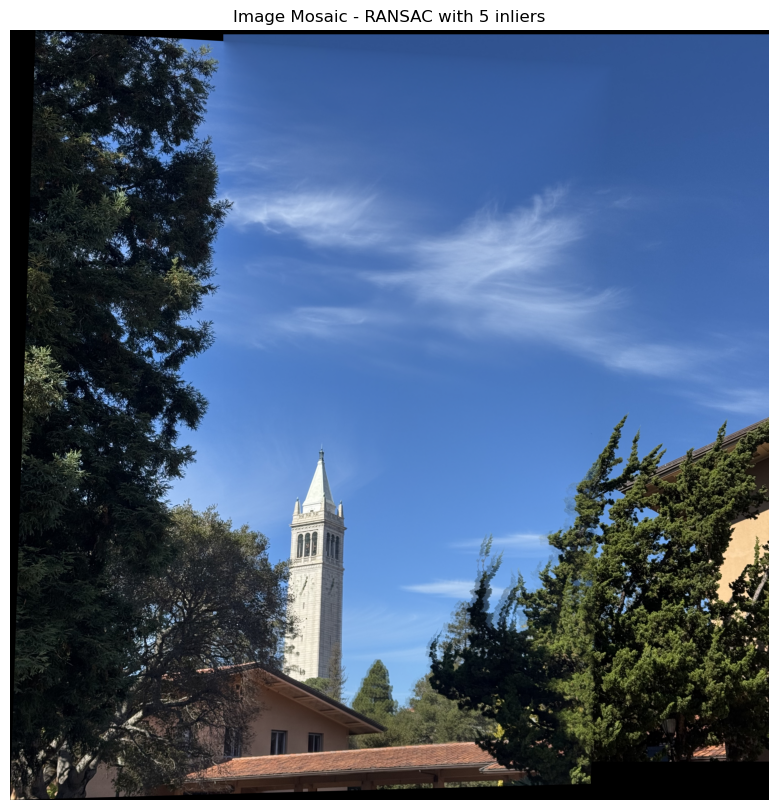

True

In [143]:
plt.figure(figsize=(15, 10))
plt.imshow(mosaic)
plt.axis('off')
plt.title('Image Mosaic - RANSAC with 5 inliers')
plt.show()

mosaic_bgr = cv2.cvtColor(mosaic, cv2.COLOR_RGB2BGR)
cv2.imwrite('mosaic_result.jpg', mosaic_bgr)